<a href="https://colab.research.google.com/github/paarthbamb/dataScience/blob/main/Unit8/PaarBambUnit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

A decision tree is a model that makes predictions by asking a series of yes/no questions. You start at the top, follow branches based on your answers, and end up at a leaf node that gives you the final prediction. For regression (like the previous task where we predicted calories), that leaf just returns the average of all training points that landed there.

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

Depth is how many levels of splits the tree has. Too deep means it memorizes the training data and fails on new data (overfitting). Too shallow means it misses patterns (underfitting). You can tell by comparing training error vs. test error. If training is low but test is high, it's too deep.

**Task4:**

How are BART models similar and different from a decision tree?

Both use decision trees as the building block. But where a regular tree is one potentially deep tree, BART combines hundreds of small shallow trees and adds their predictions together. BART also gives you uncertainty estimates since it's Bayesian, while a regular tree just spits out one number with no sense of confidence.

**Task5**:

Why would we use a BART model instead of a decision tree?

BART is better than a single decision tree mainly because it doesn't overfit as easily. One deep tree can latch onto noise in the training data and fall apart on new observations. BART avoids this by combining lots of shallow trees, so no single tree is doing too much work. You also get uncertainty estimates for free since it's Bayesian, which a regular decision tree can't give you.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [ ]:
!pip install pymc-bart

In [ ]:
import pandas as pd
import pymc as pm
import numpy as np
import pymc_bart as pmb
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()
print(penguins.columns)

X = penguins[["flipper_length", "bill_depth", "bill_length"]].values
y = penguins["body_mass"].values

with pm.Model() as model:
    mu = pmb.BART("mu", X, y)
    sigma = pm.HalfNormal("sigma", sigma=1000)
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=y)
    idata = pm.sample(random_seed=42)

# Posterior predictive check
with model:
    idata.extend(pm.sample_posterior_predictive(idata))

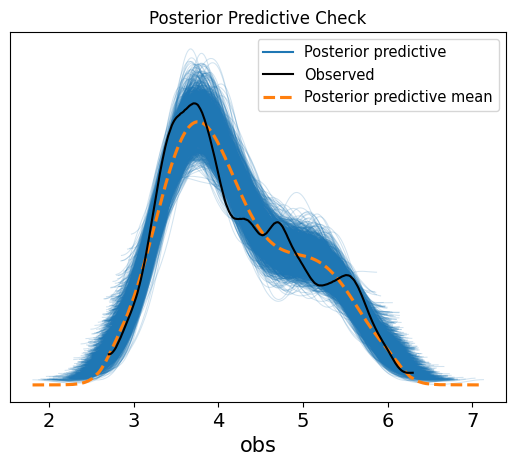

In [19]:
pm.plot_ppc(idata)
plt.title("Posterior Predictive Check")
plt.show()

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

In [20]:
import arviz as az
import matplotlib.pyplot as plt

posterior_mean = idata.posterior["mu"]

pps = az.extract(
    idata, group="posterior_predictive", var_names=["obs"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


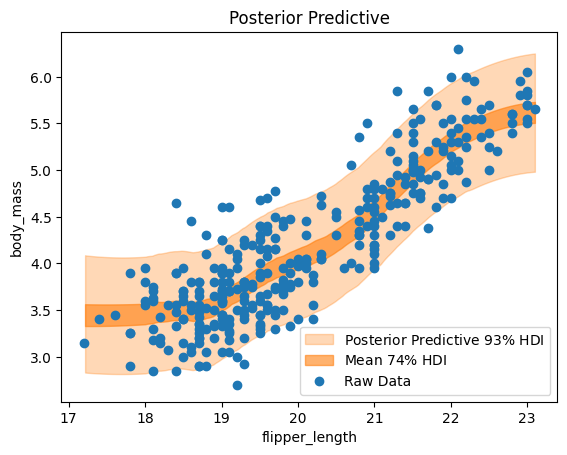

In [21]:
fig, ax = plt.subplots()

az.plot_hdi(
    x=X[:, 0],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior Predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X[:, 0],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)

ax.plot(penguins["flipper_length"], penguins["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(title="Posterior Predictive", xlabel="flipper_length", ylabel="body_mass")
plt.show()


**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

I think the model does a pretty good job capturing the association between flipper length and body mass. There's a clear positive trend in the raw data (longer flippers generally mean heavier penguins) and the posterior predictive band follows that trend well across the whole range. That said, it's not perfect. The 93% HDI band is pretty wide, especially on the left side around flipper lengths of 17-18, which suggests the model is more uncertain for smaller penguins. There's also a decent chunk of points that fall outside the band entirely, and you can see the data has kind of a spread that looks like it might actually be two or three clusters rather than one smooth trend, probably because there are multiple species mixed together. So the model captures the overall direction but might be smoothing over some species level differences that a more detailed model could pick up.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

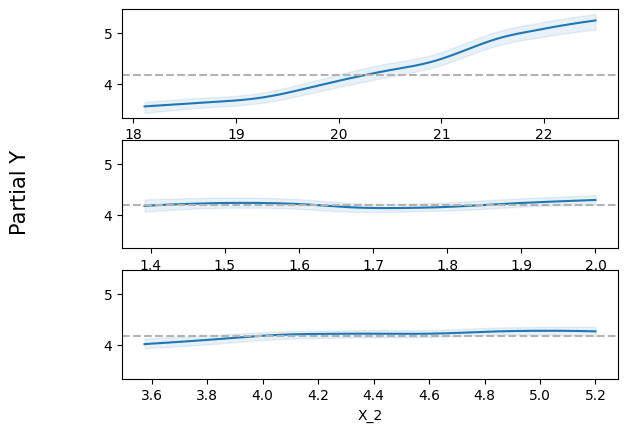

In [22]:
pmb.plot_pdp(mu, X=X, Y=y, grid="long", var_discrete=[])
plt.show()

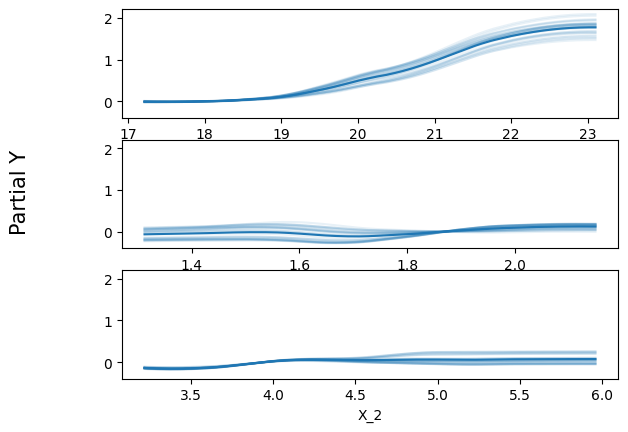

In [23]:
pmb.plot_ice(mu, X=X, Y=y, grid="long", var_discrete=[])
plt.show()

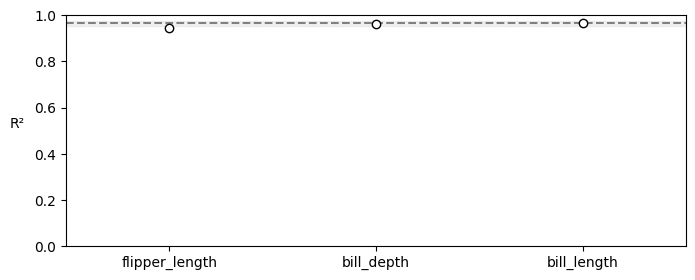

In [31]:
vi_results = pmb.compute_variable_importance(idata, mu, X, y)
pmb.plot_variable_importance(vi_results, labels=["flipper_length", "bill_depth", "bill_length"])
plt.show()

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

Based on the plots, flipper length is clearly the most important variable for predicting body mass. In the PDP, flipper length shows a strong positive relationship: as flipper length increases from 18 to 23, the predicted body mass goes up pretty significantly. The other two variables, bill depth and bill length, are basically flat lines in the PDP, which suggests they don't add much on their own once you account for flipper length. The variable importance plot confirms this as the R² barely changes when you add bill depth and bill length after flipper length is already in the model.

The ICE plots shows that flipper length has a clear upward trend across individual penguins, while bill depth and bill length are nearly flat for most observations, meaning the model isn't picking up much of a relationship there.

As for interactions, it's hard to say there's strong evidence of them here. The ICE lines for flipper length are pretty parallel to each other, which would suggest the effect of flipper length on body mass is fairly consistent across penguins and isn't being moderated much by the other variables. If there were big interactions, you'd expect the ICE lines to cross or fan out.